In [ ]:
import numpy as np
import matplotlib.pyplot as plt  
import os
import glob # Import the glob module

In [2]:
%cd /content
!ls


/content
sample_data


In [3]:
import os
if os.path.exists('/content'):
    print("Running in Google Colab environment.")
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pwd
!ls '/content/drive/MyDrive/Colab Notebooks/ModernComputerVisionWithPytorch'

/content
git_config.py  GitHub_repository_management.ipynb  repo-clone.py  Untitled


In [5]:
%run -i '/content/drive/MyDrive/Colab Notebooks/ModernComputerVisionWithPytorch/git_config.py'

Repo cloned to: /content/modern-computer-vision-with-pytorch-2e


In [10]:
dir_repo

'/content/modern-computer-vision-with-pytorch-2e'

In [11]:
%cd {dir_repo}
!pip install -r requirements.txt

/content/modern-computer-vision-with-pytorch-2e


In [12]:
secrets_dir

PosixPath('/content/drive/MyDrive/.secrets')

In [ ]:
# %pip install -q kaggle

In [13]:
# !pip install --force-reinstall --no-cache-dir git+https://github.com/fsansegundo/torch_snippets.git

In [14]:
with open(secrets_dir / 'kaggle_user.txt') as f:
    kaggle_user = f.read().strip()
with open(secrets_dir / 'kaggle_key.txt') as f:
    kaggle_key = f.read().strip()

# ---------------------------------------------------------------------------
# Configure git
# ---------------------------------------------------------------------------
os.environ['KAGGLE_USERNAME'] = kaggle_user
os.environ['KAGGLE_KEY'] = kaggle_key

In [27]:
import os
from google.colab import userdata


# 2. Replicate the expected file structure for the Kaggle CLI
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# 3. Create the actual kaggle.json file programmatically in the correct hidden folder
import json
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump({"username": os.environ["KAGGLE_USERNAME"], "key": os.environ["KAGGLE_KEY"]}, f)

# 4. Set restrictive read/write permissions for security (Required by Kaggle API)
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)

print("Kaggle API configured.")

Kaggle API configured.


In [ ]:
# #copy kaggle.json to the right place from already existing secrets_dir
# os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# # os.file.copy(os.path.join(secrets_dir, 'kaggle.json'), os.path.expanduser('~/.kaggle/kaggle.json'))

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !ls ~/.kaggle
# !chmod 600 kaggle.json


In [15]:
!pwd
# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)
# Change to the data directory
os.chdir('data')

/content/modern-computer-vision-with-pytorch-2e


In [16]:
!pwd

/content/modern-computer-vision-with-pytorch-2e/data


In [18]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria
!unzip -qq cell-images-for-detecting-malaria.zip

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:17<00:00, 40.9MB/s] 



In [19]:
from torch_snippets import *

In [20]:
id2int = {'Parasitized': 0, 'Uninfected': 1}

In [21]:
from torchvision import transforms as T

trn_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(128),
    T.CenterCrop(128),
    T.ColorJitter(brightness=(0.95,1.05), 
                  contrast=(0.95,1.05), 
                  saturation=(0.95,1.05), 
                  hue=0.05),
    T.RandomAffine(5, translate=(0.01,0.1)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], 
                std=[0.5, 0.5, 0.5]),
])

In [22]:
val_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(128),
    T.CenterCrop(128),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], 
                std=[0.5, 0.5, 0.5]),
])

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader

class MalariaImages(Dataset):

    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
        logger.info(len(self))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, ix):
        fpath = self.files[ix]
        clss = fname(parent(fpath))
        img = read(fpath, 1)
        return img, clss

    def choose(self):
        return self[randint(len(self))]

    def collate_fn(self, batch):
        _imgs, classes = list(zip(*batch))
        if self.transform:
            imgs = [self.transform(img)[None] for img in _imgs]
        classes = [torch.tensor([id2int[clss]]) for clss in classes]
        imgs, classes = [torch.cat(i).to(device) for i in [imgs, classes]]
        return imgs, classes, _imgs

In [24]:
# Find out which cuda device is available


In [ ]:
!pwd


/content/modern-computer-vision-with-pytorch-2e/data


In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_files = glob.glob('./cell_images/*/*.png')
np.random.seed(10)
np.random.shuffle(all_files)

from sklearn.model_selection import train_test_split
trn_files, val_files = train_test_split(all_files, random_state=1)

trn_ds = MalariaImages(trn_files, transform=trn_tfms)
val_ds = MalariaImages(val_files, transform=val_tfms)
trn_dl = DataLoader(trn_ds, 32, shuffle=True, collate_fn=trn_ds.collate_fn)
val_dl = DataLoader(val_ds, 32, shuffle=False, collate_fn=val_ds.collate_fn)

[06/02/26 13:09:28] INFO     20668                                                                                                                  ]8;id=14507414;file:///tmp/ipykernel_5066/2319917090.py:9\2319917090.py]8;;\:]8;id=14507415;file:///tmp/ipykernel_5066/2319917090.py:9#__init__:9\__init__:9]8;;\

                    INFO     6890                                                                                                                   ]8;id=14507420;file:///tmp/ipykernel_5066/2319917090.py:9\2319917090.py]8;;\:]8;id=14507421;file:///tmp/ipykernel_5066/2319917090.py:9#__init__:9\__init__:9]8;;\

In [27]:
import torch.nn as nn


def convBlock(ni, no):
    return nn.Sequential(
        nn.Dropout(0.2),
        nn.Conv2d(ni, no, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(no),
        nn.MaxPool2d(2),
    )
    
class MalariaClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            convBlock(3, 64),
            convBlock(64, 64),
            convBlock(64, 128),
            convBlock(128, 256),
            convBlock(256, 512),
            convBlock(512, 64),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.Dropout(0.2),
            nn.ReLU(inplace=True),
            nn.Linear(256, len(id2int))
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def compute_metrics(self, preds, targets):
        loss = self.loss_fn(preds, targets)
        acc = (torch.max(preds, 1)[1] == targets).float().mean()
        return loss, acc

In [28]:
def train_batch(model, data, optimizer, criterion):
    model.train()
    ims, labels, _ = data
    _preds = model(ims)
    optimizer.zero_grad()
    loss, acc = criterion(_preds, labels)
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, data, criterion):
    model.eval()
    ims, labels, _ = data
    _preds = model(ims)
    loss, acc = criterion(_preds, labels)
    return loss.item(), acc.item()

In [29]:
from torch import optim

model = MalariaClassifier().to(device)
criterion = model.compute_metrics
optimizer = optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 2

log = Report(n_epochs)
for ex in range(n_epochs):
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss, acc = train_batch(model, data, optimizer, criterion)
        log.record(ex+(bx+1)/N, trn_loss=loss, trn_acc=acc, end='\r')

    N = len(val_dl)
    for bx, data in enumerate(val_dl):
        loss, acc = validate_batch(model, data, criterion)
        log.record(ex+(bx+1)/N, val_loss=loss, val_acc=acc, end='\r')
        
    log.report_avgs(ex+1)

EPOCH: 1.000  val_acc: 0.929  trn_acc: 0.900  trn_loss: 0.250  val_loss: 0.225  (256.06s - 256.06s remaining)
EPOCH: 2.000  val_acc: 0.950  trn_acc: 0.944  trn_loss: 0.172  val_loss: 0.170  (515.97s - 0.00s remaining)


In [30]:
im2fmap = nn.Sequential(*(list(model.model[:5].children()) + list(model.model[5][:2].children())))

In [31]:
def im2gradCAM(x):
    model.eval()
    logits = model(x)
    heatmaps = []
    activations = im2fmap(x)
    print(activations.shape)
    pred = logits.max(-1)[-1]
    # get the model's prediction
    model.zero_grad()
    # compute gradients with respect to model's most confident logit
    logits[0,pred].backward(retain_graph=True)
    # get the gradients at the required featuremap location
    # and take the avg gradient for every featuremap
    pooled_grads = model.model[-6][1].weight.grad.data.mean((1,2,3))
    # multiply each activation map with corresponding gradient average
    for i in range(activations.shape[1]):
        activations[:,i,:,:] *= pooled_grads[i]
    # take the mean of all weighted activation maps
    # (that has been weighted by avg. grad at each fmap)
    heatmap = torch.mean(activations, dim=1)[0].cpu().detach()
    return heatmap, 'Uninfected' if pred.item() else 'Parasitized'

In [32]:
import cv2


SZ = 128
def upsampleHeatmap(map, img):
    m,M = map.min(), map.max()
    map = 255 * ((map-m) / (M-m))
    map = np.uint8(map)
    map = cv2.resize(map, (SZ,SZ))
    map = cv2.applyColorMap(255-map, cv2.COLORMAP_JET)
    map = np.uint8(map)
    map = np.uint8(map*0.7 + img*0.3)
    return map

torch.Size([1, 64, 4, 4])


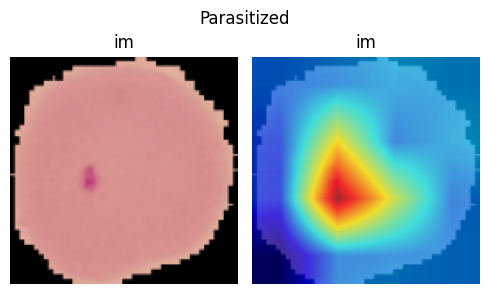

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


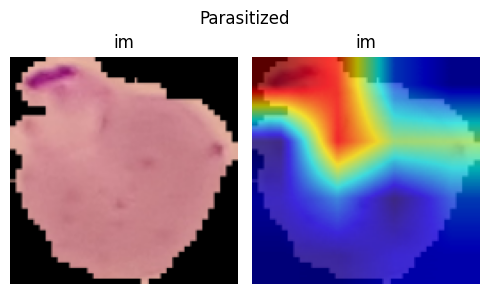

torch.Size([1, 64, 4, 4])


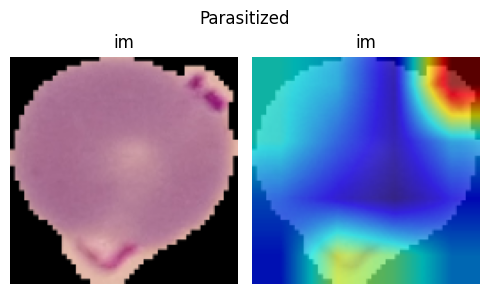

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


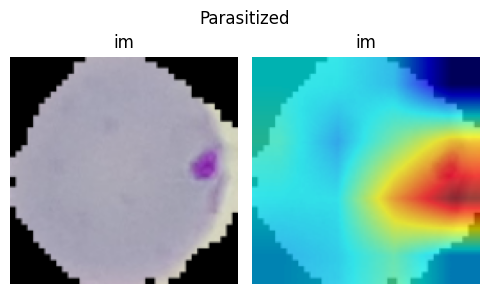

torch.Size([1, 64, 4, 4])


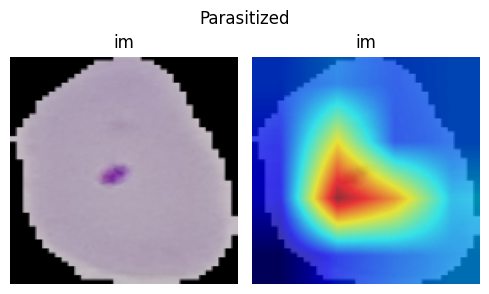

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


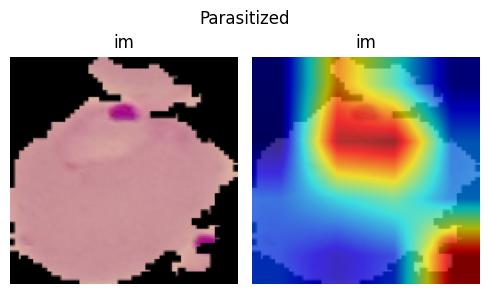

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


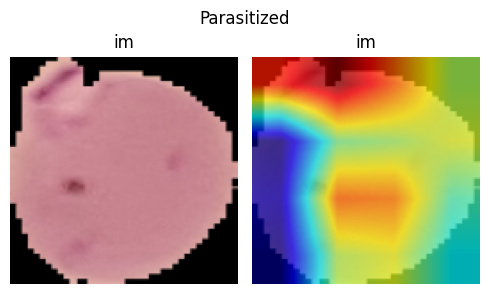

torch.Size([1, 64, 4, 4])


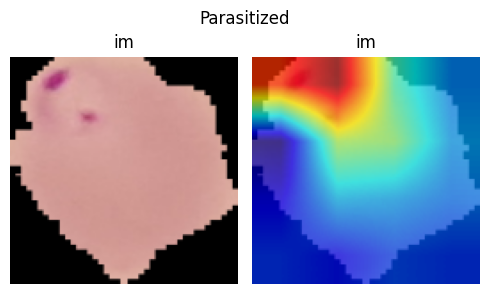

torch.Size([1, 64, 4, 4])


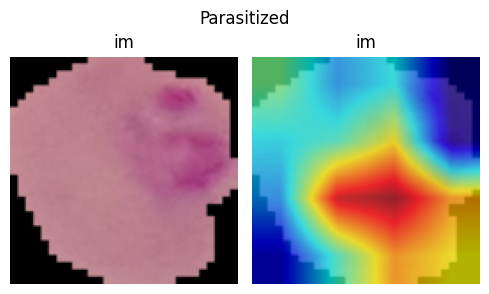

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


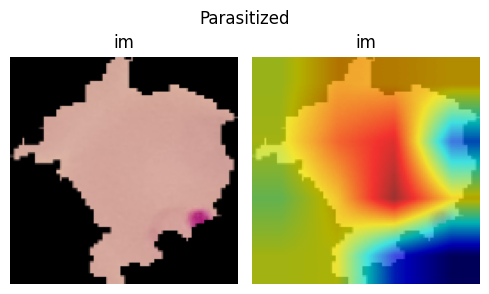

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


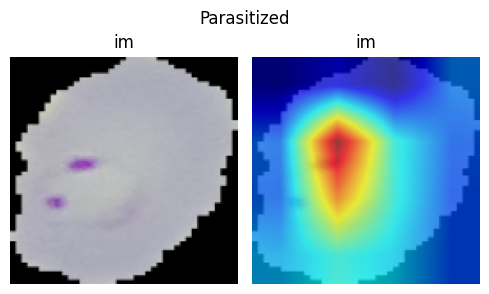

In [33]:

N = 20
_val_dl = DataLoader(val_ds, batch_size=N, shuffle=True, collate_fn=val_ds.collate_fn)
x,y,z = next(iter(_val_dl))

for i in range(N):
    image = resize(z[i], SZ)
    heatmap, pred = im2gradCAM(x[i:i+1])
    if(pred=='Uninfected'):
        continue
    heatmap = upsampleHeatmap(heatmap, image)
    subplots([image, heatmap], nc=2, figsize=(5,3), suptitle=pred)